In [13]:
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.utils import to_categorical

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [52]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [53]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [54]:
print(y_train)
print(x_train.shape)
# print(y_test)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(60000, 28, 28)


In [55]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [56]:
print(x_train.shape)

(60000, 28, 28, 1)


In [57]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 klas
])

In [58]:
# model = Sequential()
# model.add(Conv2D(32, kernel_size=(3, 3), input_shape = (28, 28, 1), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
# model.add(Flatten())
# model.add(Dense(32, activation='relu'))
# model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [59]:
# Trenowanie modelu 
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6981 - loss: 0.8392 - val_accuracy: 0.8578 - val_loss: 0.3854
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8480 - loss: 0.4263 - val_accuracy: 0.8811 - val_loss: 0.3261
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8712 - loss: 0.3607 - val_accuracy: 0.8900 - val_loss: 0.2955
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8816 - loss: 0.3253 - val_accuracy: 0.8962 - val_loss: 0.2767
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8920 - loss: 0.2972 - val_accuracy: 0.9030 - val_loss: 0.2624
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8967 - loss: 0.2748 - val_accuracy: 0.9022 - val_loss: 0.2626
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9065 - loss: 0.2561 - val_accuracy: 0.9067 - val_loss: 0.2510
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9083 - los

In [60]:
# Ocena modelu 
test_acc = model.evaluate(x_test, y_test)
print('Dokładność klasyfikacji:', test_acc) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9058 - loss: 0.2731
Dokładność klasyfikacji: [0.2704373598098755, 0.9067000150680542]


In [61]:
# Predykcje
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)
print(y_pred_labels)
print(y_test_labels)
conf_matrix = confusion_matrix(y_pred_labels, y_test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[9 2 1 ... 8 1 5]
[9 2 1 ... 8 1 5]


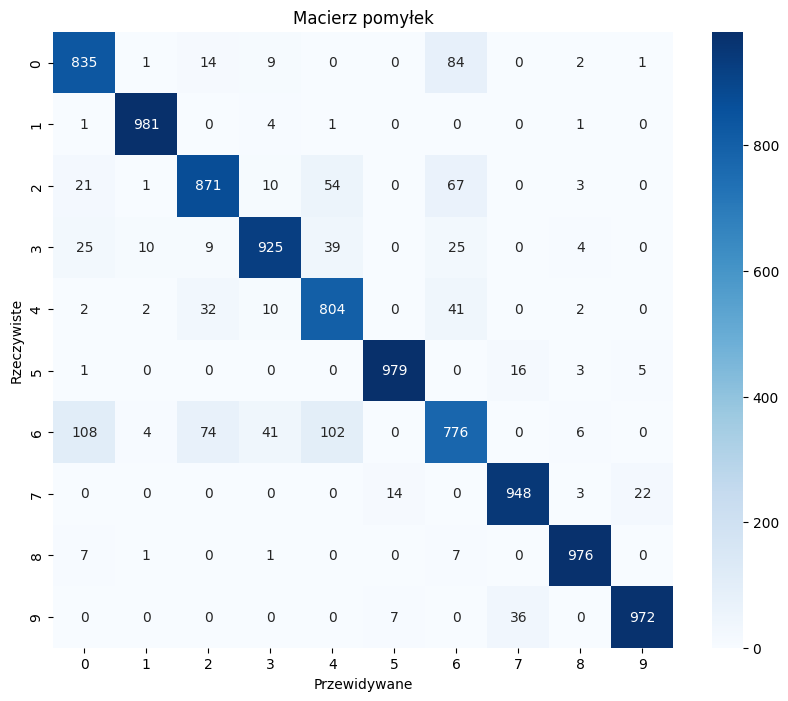

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Macierz pomyłek")
plt.xlabel("Przewidywane")
plt.ylabel("Rzeczywiste")
plt.show()

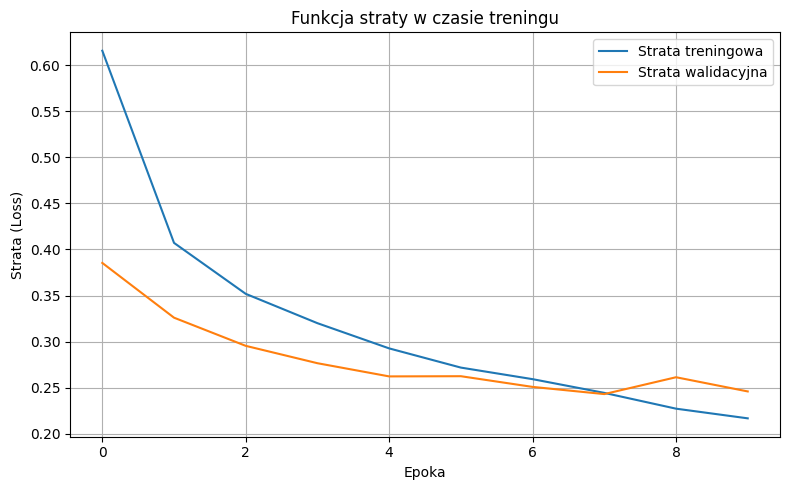

In [63]:
# Wykres funkcji straty i walidacyjnej straty
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Strata treningowa')
plt.plot(history.history['val_loss'], label='Strata walidacyjna')
plt.title('Funkcja straty w czasie treningu')
plt.xlabel('Epoka')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Klasa 6 (Shirt) to najtrudniejsza klasa:

Jest często mylona z innymi (0, 2, 4),

Sama też pochłania dużo błędnych predykcji z innych klas.

Strata treningowa i walidacyjna maleją stabilnie – to znaczy, że model uczy się prawidłowo.

Brak dużego rozjazdu między krzywymi → nie występuje silne przeuczenie (overfitting)
Na końcu widać lekkie „podskoczenie” straty walidacyjnej → może to być losowa fluktuacja, ale warto obserwować.


Można spróbować dodać jeszcze kolejne warstwy, więcej neuronóew

Zrobić walidacje krzyżową

Zrobić wykres accuracy

Augmentacja danych, wcześniej uczony model